In [15]:
#%pip install pandas matplotlib seaborn sqlalchemy ipython-sql
#%pip install tabulate

This notebook reproduces the empirical results in:

**“ ”**

It constructs the key variables from market data and replicates the figures used in the main text.

All notation follows the blog post.

In [16]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///obstfeld.db')

csv_files = ['lunc-usd-max.csv', 'ustc-usd-max.csv']

for file in csv_files:
    try:
        table_name = file.split('.')[0]

        df = pd.read_csv(file)
        df.to_sql(table_name, engine, if_exists='replace', index=False)
        print('Successful')
    except Exception as e:
        print('Failed due to {e}')

Successful
Successful


## Mapping Theory to Data

From the model:

- $x_t$: redemptions  
- $p_t$: LUNA price  
- $\frac{x_t}{p_t}$: minting pressure  

In the data:

- Redemptions are proxied by changes in UST supply  
- LUNA supply is computed as market cap divided by price  
- Reflexivity ratio is constructed as:

$$
\frac{x_t}{p_t}
$$

## Data Construction

We use price and market capitalization data for UST and LUNA.

From this:

- Supply = market cap / price  
- Redemptions = $\Delta$ UST supply 

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

query = """
WITH luna AS (SELECT datetime(REPLACE(snapped_at, ' UTC', '')) AS t, price AS L_price, market_cap/price AS L_supply
FROM "lunc-usd-max"
WHERE datetime(REPLACE(snapped_at, ' UTC', '')) BETWEEN '2022-05-05' AND '2022-05-16'), 

ust AS ( select *, lag(U_supply) over (order by t) as prev_U_supply
from
(SELECT datetime(REPLACE(snapped_at, ' UTC', '')) AS t, price AS U_price, market_cap/price AS U_supply
FROM "ustc-usd-max"
WHERE datetime(REPLACE(snapped_at, ' UTC', '')) BETWEEN '2022-05-05' AND '2022-05-16')
)

SELECT l.t, l_price, l_supply, u_price, u_supply, prev_u_supply - u_supply as redemptions, (prev_u_supply - u_supply)/l_price as ref_ratio
from luna l
left join ust u
on l.t = u.t
order by l.t
"""

df = pd.read_sql(query, engine)
df['t'] = pd.to_datetime(df['t'])
df = df.sort_values('t')


In [26]:
print(df.columns.tolist())

['t', 'L_price', 'L_supply', 'U_price', 'U_supply', 'redemptions', 'ref_ratio']


### UST Price

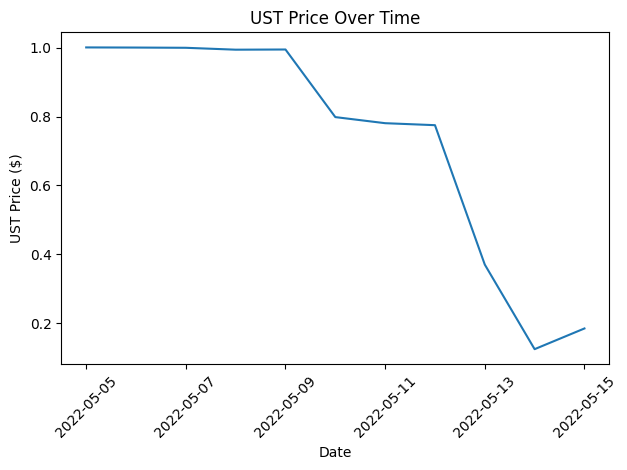

In [32]:
plt.figure()
plt.plot(df['t'], df['U_price'])
plt.title("UST Price Over Time")
plt.xlabel("Date")
plt.ylabel("UST Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
import tabulate

def format_supply(n):
    if n >= 1e12: return f"{n/1e12:.2f} Trillion"
    if n >= 1e9:  return f"{n/1e9:.2f} Billion"
    if n >= 1e6:  return f"{n/1e6:.2f} Million"
    return f"{n:,.0f}"
df['LSupply'] = df['L_supply'].apply(format_supply)
df['LPrice'] = df['L_price'].map('${:,.4f}'.format)
df['USupply'] = df['U_supply'].apply(format_supply)
df['UPrice'] = df['U_price'].map('${:,.4f}'.format)
df['date'] = df['t']
display_df = df[['date', 'LSupply', 'LPrice', 'USupply', 'UPrice']]

print(display_df.to_markdown(index=False, tablefmt="grid"))

+---------------------+----------------+----------+---------------+----------+
| date                | LSupply        | LPrice   | USupply       | UPrice   |
+=====================+================+==========+===============+==========+
| 2022-05-05 00:00:00 | 344.06 Million | $86.1360 | 18.68 Billion | $1.0012  |
+---------------------+----------------+----------+---------------+----------+
| 2022-05-06 00:00:00 | 343.03 Million | $82.6197 | 18.66 Billion | $1.0008  |
+---------------------+----------------+----------+---------------+----------+
| 2022-05-07 00:00:00 | 342.49 Million | $77.5648 | 18.77 Billion | $1.0002  |
+---------------------+----------------+----------+---------------+----------+
| 2022-05-08 00:00:00 | 343.20 Million | $68.5773 | 18.81 Billion | $0.9947  |
+---------------------+----------------+----------+---------------+----------+
| 2022-05-09 00:00:00 | 342.84 Million | $63.8564 | 18.73 Billion | $0.9952  |
+---------------------+----------------+----------+-

### Luna Price ($p_t$) Mapped Against Luna Supply ($L_t$)

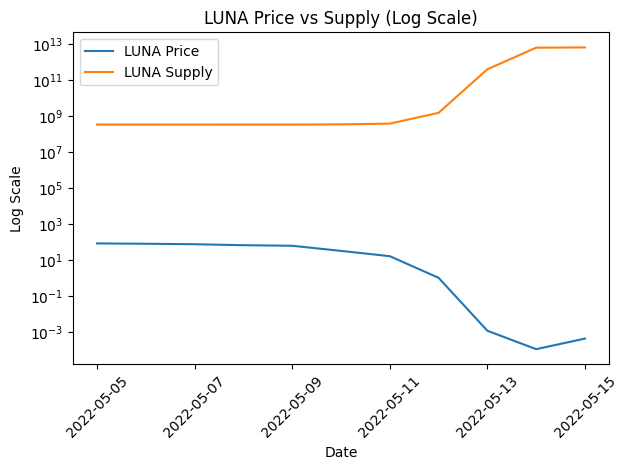

In [34]:
plt.figure()

plt.plot(df['t'], df['L_price'], label='LUNA Price')
plt.plot(df['t'], df['L_supply'], label='LUNA Supply')

plt.yscale('log')

plt.title("LUNA Price vs Supply (Log Scale)")
plt.xlabel("Date")
plt.ylabel("Log Scale")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Reflexivity Pressure ($x_t / p_t$)


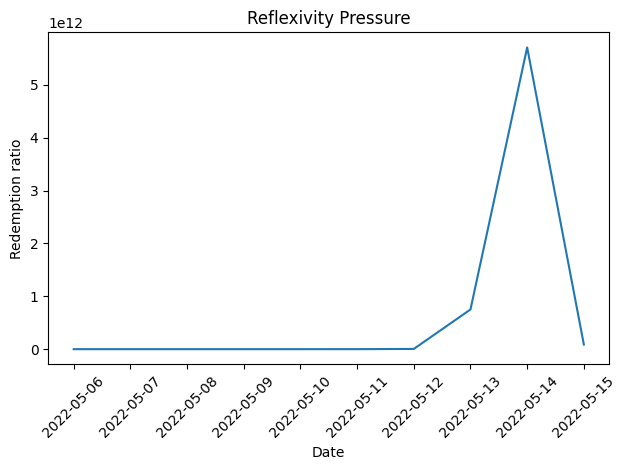

In [35]:
plt.figure()
plt.plot(df['t'], df['ref_ratio'])
plt.title("Reflexivity Pressure")
plt.xlabel("Date")
plt.ylabel("Redemption ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The reflexivity ratio increases sharply during the collapse.

As $p_t$ declines, each unit of redemption requires minting more LUNA, amplifying supply expansion and reinforcing downward price pressure.